In [2]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from fenics import *
from utils.mesh_utils import get_square_f
from utils.metrics import SpaceIndexing, error_centroid, error_movers, error_iou, error_ssim
from algorithms.matrix_free_rsvd import MatrixFreeRSVD, tikhonov_solver, get_approximate_W
from utils.exact_forward_operator import ExactForwardOperator, solve_explicit
from utils.metrics import SpaceIndexing
from utils.utils import progress_bar
from utils.colors import CMAP

SEED = 15

/home/elias/miniforge3/envs/fenics_env/lib/python3.9/site-packages/ufl/__init__.py:250: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
def get_source(V_h, x0_list, y0_list, width, height):
    x = np.zeros(V_h.dim())
    for x0, y0 in zip(x0_list, y0_list):
        f = get_square_f(V_h, x0=x0, y0=y0, w=width, h=height)
        x += f.vector().get_local()

    f = Function(V_h)
    f.vector()[:] = x
    return f, x


def experiment_rsvd_over_k(x_exact, k_range, lambda_, V_h, repeat=1):
    indexing = SpaceIndexing(V_h)
    nk = len(k_range)

    records = []
    step = 0
    for i, k in enumerate(k_range):
        for r in range(repeat):
            step += 1

            # Solve inverse problem using matrix-free rSVD
            U, S, VT = rsvd.mf_rsvd(k=k, seed=SEED + r)

            w = get_approximate_W(VT.T, rsvd.M_dx)
            x_hat = tikhonov_solver(rsvd, w, y, lambda_=lambda_)

            # Measure the error
            record = {
                'k': k,
                'repeat': r,
                'euclidean': np.linalg.norm(x_exact - x_hat),
                'centroid': error_centroid(x_exact, x_hat),
                'movers': error_movers(x_exact, x_hat),
                'iou': error_iou(x_exact, x_hat, indexing),
                'ssim': error_ssim(x_exact, x_hat, indexing)
            }

            records.append(record)
            progress_bar(step, nk * repeat, end_text=f" [k={k}]")

    return pd.DataFrame(records)


def experiment_exact(x, V_h):
    exact = ExactForwardOperator(V_h)
    K = exact.K
    w = exact.get_weights()

    f_hat = solve_explicit(operator=exact, w=w, y=y, lambda_=1e-4)
    x_hat = f_hat.vector().get_local()

    indexing = SpaceIndexing(V_h)
    record_exact = {
        'euclidean': np.linalg.norm(x - x_hat),
        'centroid': error_centroid(x, x_hat),
        'movers': error_movers(x, x_hat),
        'iou': error_iou(x, x_hat, indexing),
        'ssim': error_ssim(x, x_hat, indexing)
    }
    return record_exact


def plot_rsvd_over_k(df, df_exact):
    stats = df.groupby("k").agg(["mean", "std", "count"])

    fig, axes = plt.subplots(2, 2, sharex=True)
    axes = axes.flatten()

    dists = ['Euclidean', 'Movers', 'IoU', 'SSIM']

    for ax, dist in zip(axes, dists):
        key = dist.lower()

        mean = stats[(key, "mean")]
        std = stats[(key, "std")]
        n = stats[(key, "count")]

        ci95 = 1.96 * std / np.sqrt(n)
        k_vals = mean.index

        ax.axhline(df_exact[key][0], c='r', ls='--')

        ax.plot(k_vals, mean)
        ax.fill_between(k_vals, mean - ci95, mean + ci95, alpha=0.25)

        ax.grid(alpha=.5)
        ax.set_title(dist)

    plt.tight_layout()


---

In [5]:
# Function space
n = 64
mesh = UnitSquareMesh(n, n)
V_h = FunctionSpace(mesh, 'CG', 1)

# Matrix-free rSVD
rsvd = MatrixFreeRSVD(V_h)

# Get x and y
width, height = 0.15, 0.15
x0_list, y0_list = [0.2], [0.2]
f, x = get_source(V_h, x0_list, y0_list, width, height)
y = rsvd.apply_K(x)


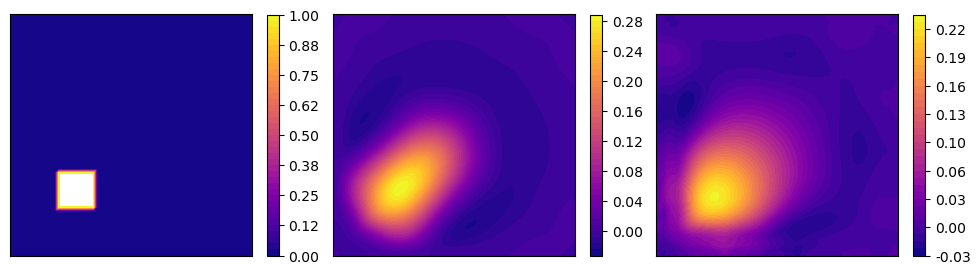

In [6]:
def plot_solutions(f_list, fig_name=None):
    fig, axes = plt.subplots(1, 3, figsize=(10, 4))
    axes = axes.flatten()

    for i, (ax, fi) in enumerate(zip(axes, f_list)):
        plt.sca(ax)
        p = plot(fi, cmap=CMAP)

        fig.colorbar(p, ax=ax, format="%.2f", shrink=0.65)
        ax.set_xticks([])
        ax.set_yticks([])
 
        # Plot square
        #if i != 0:
        #    square = patches.Rectangle((x0, y0), width, height, edgecolor='white', facecolor='none')
        #    ax.add_patch(square)

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.07)
    if fig_name is not None:
        plt.savefig(f'../figures/{fig_name}', dpi=300, bbox_inches='tight')
    plt.show()

    plt.show()

def plot_problem(V_h, f_true, k=25, fig_name=None, **kwargs):
    # Show the true solution
    f_list = [f_true]

    # Example of full rank
    exact = ExactForwardOperator(V_h)
    f_hat = solve_explicit(operator=exact, w=exact.get_weights(), y=y, lambda_=1e-4)
    f_list.append(f_hat)

    # Example of rSVD
    U, S, VT = rsvd.mf_rsvd(k=k, seed=SEED)
    w = get_approximate_W(VT.T, rsvd.M_dx)
    x_hat = tikhonov_solver(rsvd, w, y, lambda_=1e-4, **kwargs)
    f_hat = Function(V_h)
    f_hat.vector()[:] = x_hat
    f_list.append(f_hat)

    plot_solutions(f_list, fig_name)


plot_problem(V_h, f, k=20, fig_name='problem_I')

In [ ]:
k_range = np.arange(5, 100)
df = experiment_rsvd_over_k(x, k_range, lambda_=1e-4, V_h=V_h, repeat=50)

[##############################] 4750/4750 [k=99]


In [73]:
file_name = '13_rsvd_over_k.csv'
path = '../results/'

file_name = path + file_name
if os.path.exists(file_name):
    print(file_name, "already exists. Loading file")
    df = pd.read_csv(file_name)
else:
    print("Saving file as", file_name)
    df.to_csv(file_name)


Saving file as ../results/13_rsvd_over_k.csv


In [197]:
record_exact = experiment_exact(x, V_h)
df_exact = pd.DataFrame([record_exact])
df_exact.to_csv('../results/13_df_exact.csv')

Assembling S...
Assembling T...


---

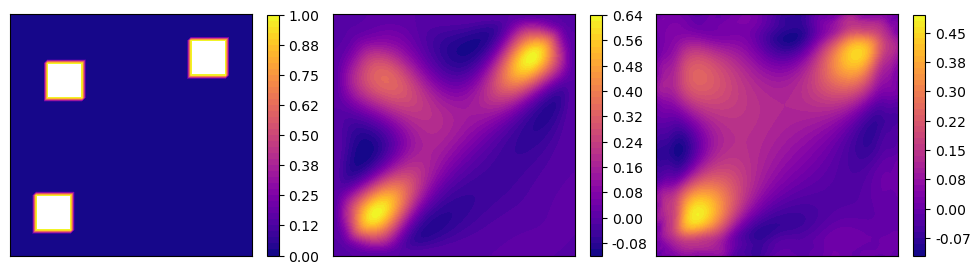

In [7]:
x0s = [0.1, 0.75, 0.15]
y0s = [0.1, 0.75, 0.65]
f, x = get_source(V_h, x0s, y0s, 0.15, 0.15)
y = rsvd.apply_K(x)

plot_problem(V_h, f, k=20, fig_name='problem_II')

In [ ]:
k_range = np.arange(5, 100)
df = experiment_rsvd_over_k(x, k_range, lambda_=1e-4, V_h=V_h, repeat=50)

[##############################] 4750/4750 [k=99]
Assembling S...
Assembling T...


In [190]:
record_exact = experiment_exact(x, V_h)
df_exact = pd.DataFrame([record_exact])
df_exact.to_csv('../results/13_df_exact_II.csv')

Assembling S...
Assembling T...


In [80]:
file_name = '13_rsvd_over_k_II.csv'
path = '../results/'

file_name = path + file_name
if os.path.exists(file_name):
    print(file_name, "already exists. Loading file")
    df = pd.read_csv(file_name)
else:
    print("Saving file as", file_name)
    df.to_csv(file_name)

Saving file as ../results/13_rsvd_over_k_II.csv


---

In [9]:
import importlib
from utils.mesh_utils import get_L_mesh
import algorithms.matrix_free_rsvd
importlib.reload(algorithms.matrix_free_rsvd)
from algorithms.matrix_free_rsvd import tikhonov_solver

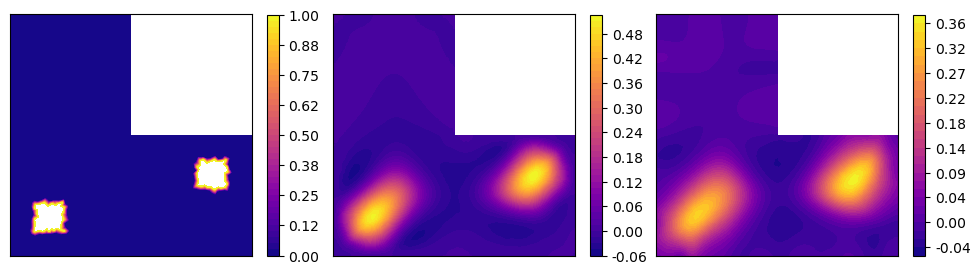

In [10]:
# Function space
n = 48
mesh = get_L_mesh(n)
V_h = FunctionSpace(mesh, 'CG', 1)

# Matrix-free rSVD
rsvd = MatrixFreeRSVD(V_h)

# Make x and y
width, height = 0.25, 0.25
x0_list, y0_list = [0.2, 1.55], [0.2, 0.55]
f, x = get_source(V_h, x0_list, y0_list, width, height)
y = rsvd.apply_K(x)

# Solve inverse problem using matrix-free rSVD
U, S, VT = rsvd.mf_rsvd(k=100, seed=SEED)
w = get_approximate_W(VT.T, rsvd.M_dx)
x_hat = tikhonov_solver(rsvd, w, y, lambda_=1e-4, rtol=1e-10)
f_hat = Function(V_h)
f_hat.vector()[:] = x_hat

f_hat = Function(V_h)
f_hat.vector()[:] = x_hat

plot_problem(V_h, f, k=20, fig_name='problem_III', rtol=1e-12)

In [129]:
from utils.metrics import vec_to_matrix

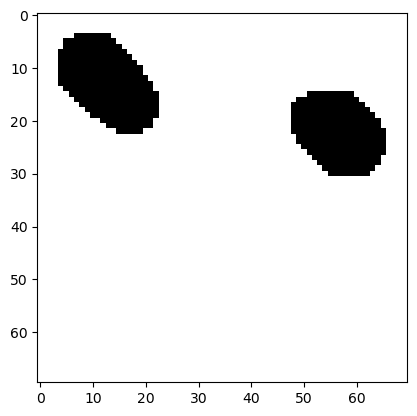

In [165]:
def rectangular_interpolation(mesh, f):
    from utils.metrics import matrix_to_vec

    coords = mesh.coordinates()

    # Calculate number of x and y nodes
    xmin, ymin = coords.min(axis=0)
    xmax, ymax = coords.max(axis=0)
    num_nodes = mesh.num_vertices()
    nx = ny = int(np.sqrt(num_nodes))
    nx, ny = int(nx*1.2), int(ny*1.2)

    # Construct mesh grid
    xs = np.linspace(xmin, xmax, nx)
    ys = np.linspace(ymin, ymax, ny)
    X, Y = np.meshgrid(xs, ys)

    # Interpolation
    Z = np.zeros_like(X)
    tree = mesh.bounding_box_tree()
    for j in range(ny):
        for i in range(nx):
            p = Point(X[j, i], Y[j, i])
            if tree.compute_first_entity_collision(p) < mesh.num_cells():
                Z[j, i] = f(p)  # evaluate f
            else:
                Z[j, i] = np.nan  # outside domain

    return Z

from utils.metrics import compute_mask
from skimage.segmentation import chan_vese

Z = rectangular_interpolation(mesh, f_hat)
Z_norm = (Z - np.nanmin(Z)) / (np.nanmax(Z) - np.nanmin(Z))

mask = chan_vese(np.nan_to_num(Z_norm))
plt.imshow(mask, cmap='gray')

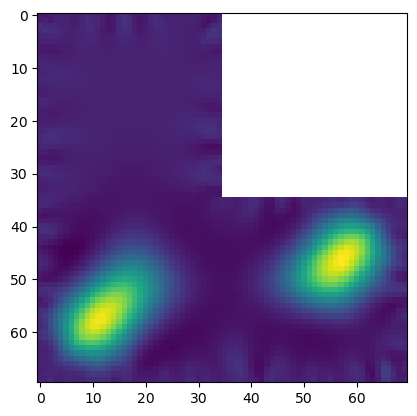

In [143]:
plt.imshow(Z[::-1])

In [130]:
indexing = SpaceIndexing(V_h)
x = vec_to_matrix(x, indexing)
#k_range = np.arange(5, 100)
#df = experiment_rsvd_over_k(x, k_range, lambda_=1e-4, V_h=V_h, repeat=50)
#record_exact = experiment_exact(x, V_h)

ValueError: cannot reshape array of size 3496 into shape (59,59)